**Clustering Analysis**

**1.data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')

In [3]:
file='EastWestAirlines.xlsx'
df=pd.read_excel(file,sheet_name='data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
#check dataset info
print('dataset shape:',df.shape)
print('\nColumns Names:')
print(df.columns.tolist())
df.info()

dataset shape: (3999, 12)

Columns Names:
['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 37

In [5]:
#check missing value
print('missing values:')
print(df.isnull().sum())

missing values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [6]:
#removing missing values
df=df.dropna()
print(df.shape)

(3999, 12)


In [7]:
print(df.duplicated().sum())

0


In [8]:
#remove duplicate values
df.drop_duplicates()
print(df.shape)

(3999, 12)


In [9]:
X=df.drop(columns=['ID#'])
X.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [10]:
#remove ID column
Q1=X.quantile(0.25)
Q3=X.quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
outliers=((X<lower_limit)|(X>upper_limit)).sum()
print('outliers in each feature:')
print(outliers)

outliers in each feature:
Balance              266
Qual_miles           226
cc1_miles              0
cc2_miles             43
cc3_miles             18
Bonus_miles          280
Bonus_trans           63
Flight_miles_12mo    569
Flight_trans_12      565
Days_since_enroll      0
Award?                 0
dtype: int64


In [11]:
outlier_mask = (
    (X < lower_limit) |
    (X > upper_limit)
).any(axis=1)
X_clean = X[~outlier_mask].copy()
print("Original Shape:", X.shape)
print("Shape after removing outliers:", X_clean.shape)

Original Shape: (3999, 11)
Shape after removing outliers: (2875, 11)


In [12]:
#scale the feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_clean.columns,
    index=X_clean.index
)
X_scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,-0.623072
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,-0.623072
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,-0.623072
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,-0.623072
5,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,-0.623072


EDA

In [13]:
X_clean.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2875.000000,2875.0,2875.000000,2875.0,2875.0,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000
mean,46840.297739,0.0,1.829913,1.0,1.0,10872.930435,9.385739,57.085217,0.198609,3926.959652,0.279652
std,42611.722286,0.0,1.154373,0.0,0.0,13664.119401,7.753492,150.711569,0.484841,2044.017792,0.448906
min,50.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,15275.000000,0.0,1.000000,1.0,1.0,500.000000,2.000000,0.000000,0.000000,2154.500000,0.000000
50%,33327.000000,0.0,1.000000,1.0,1.0,4500.000000,9.000000,0.000000,0.000000,3805.000000,0.000000
75%,65980.500000,0.0,3.000000,1.0,1.0,17089.000000,15.000000,0.000000,0.000000,5566.000000,1.000000
max,202636.000000,0.0,5.000000,1.0,1.0,57382.000000,38.000000,767.000000,2.000000,8296.000000,1.000000


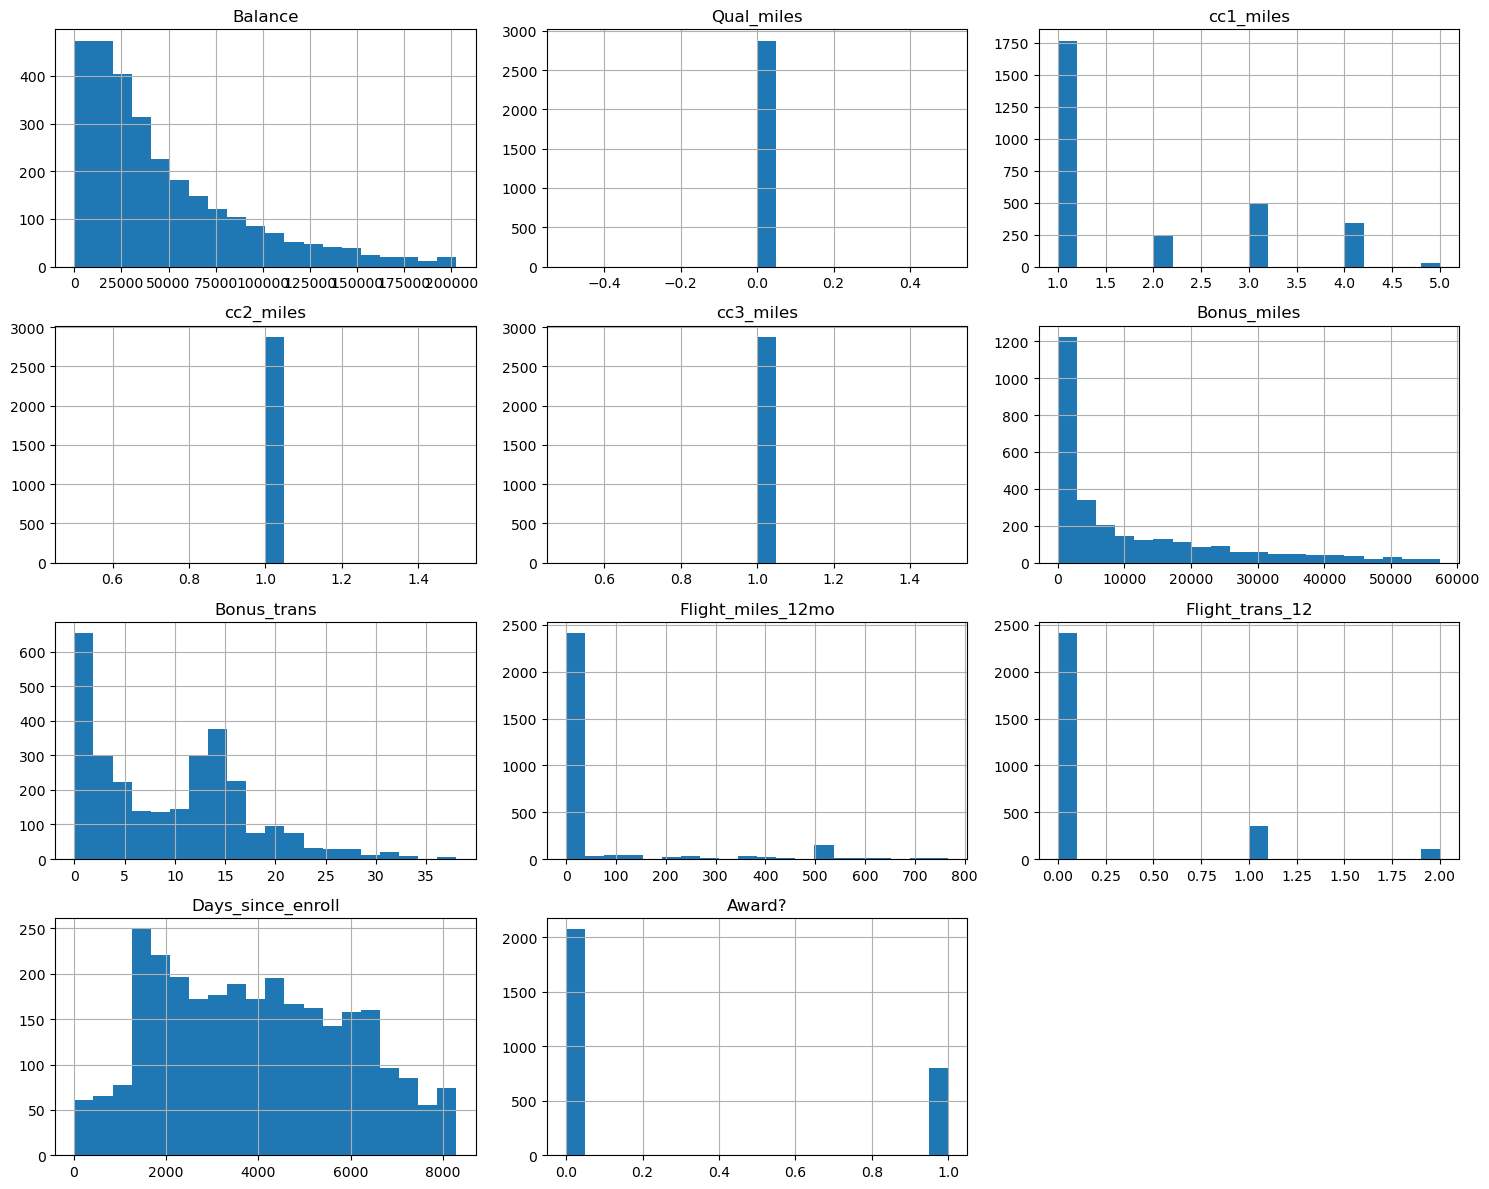

In [14]:
#dist of features
X_clean.hist(figsize=(15,12),bins=20)
plt.tight_layout()
plt.show()

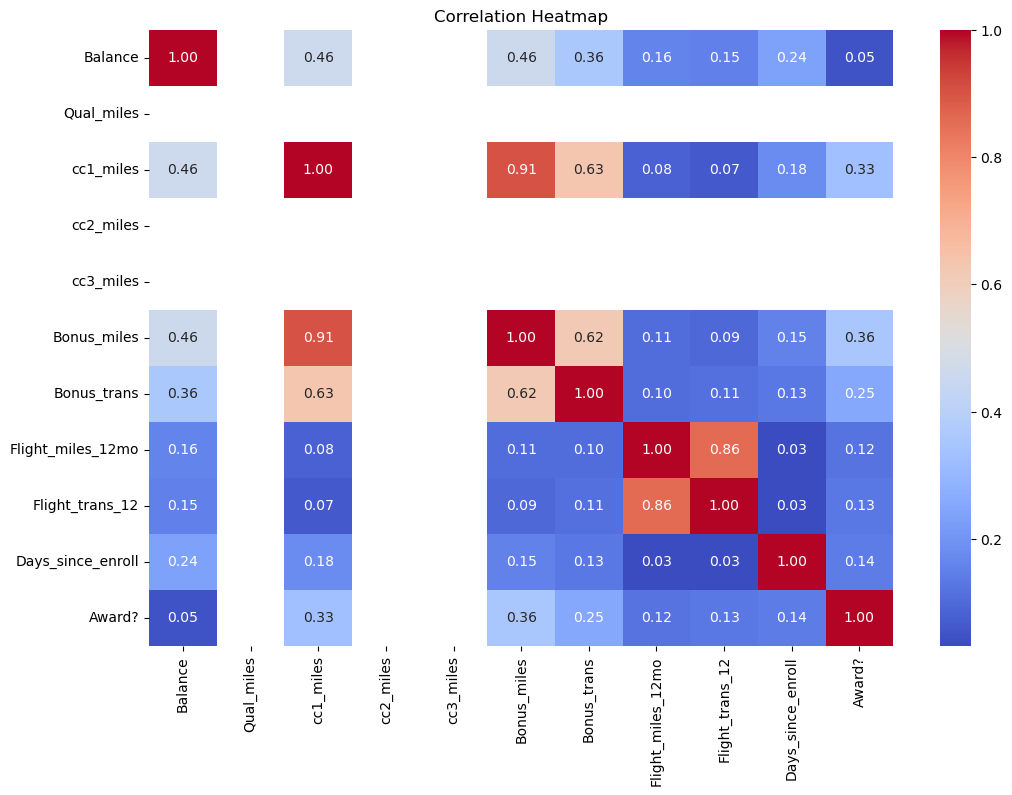

In [15]:
#correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    X_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Multiple Visualization


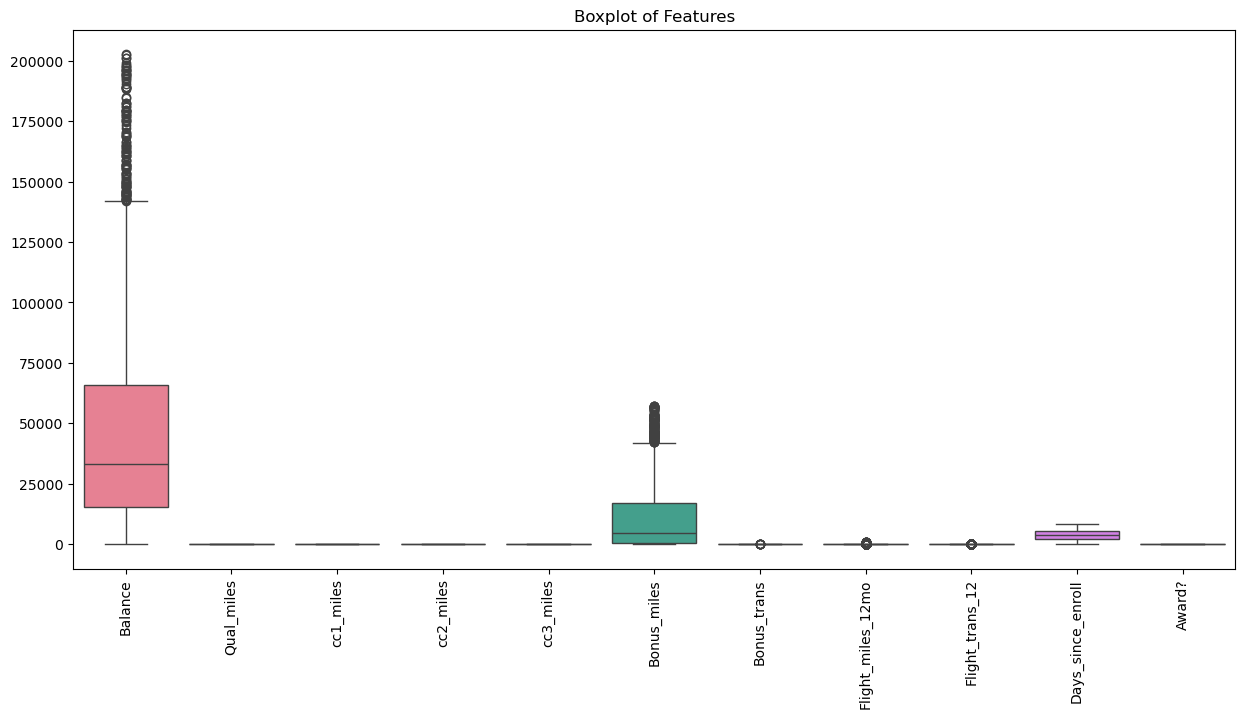

In [16]:
#Box Plot
plt.figure(figsize=(15, 7))
sns.boxplot(data=X_clean)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

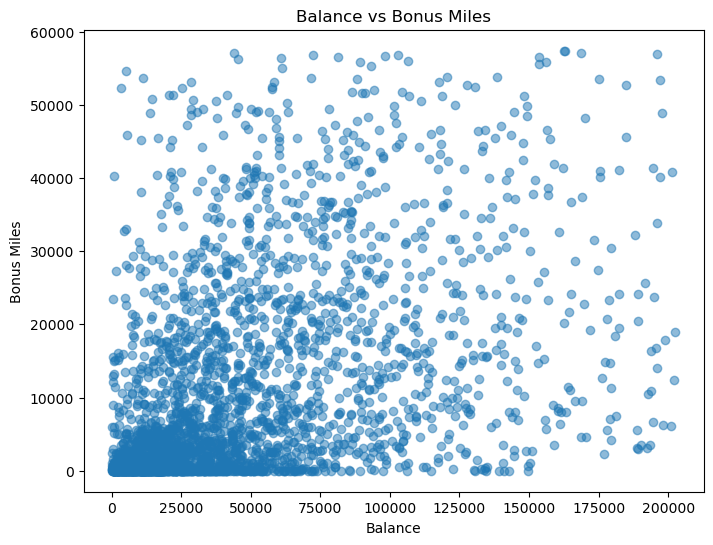

In [17]:
#scatter plot-Balance vs Bonus miles
plt.figure(figsize=(8, 6))
plt.scatter(
    X_clean["Balance"],
    X_clean["Bonus_miles"],
    alpha=0.5
)
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("Balance vs Bonus Miles")
plt.show()

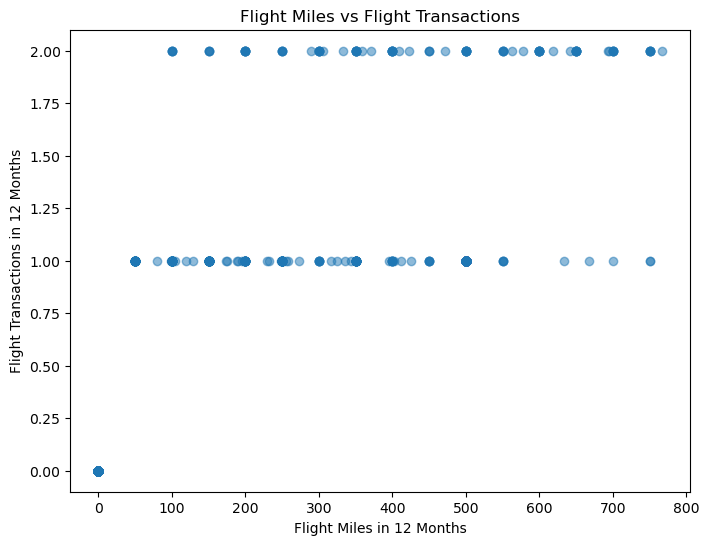

In [18]:
#scatter plot=flight miles vs flight Transactions
plt.figure(figsize=(8, 6))
plt.scatter(
    X_clean["Flight_miles_12mo"],
    X_clean["Flight_trans_12"],
    alpha=0.5
)
plt.xlabel("Flight Miles in 12 Months")
plt.ylabel("Flight Transactions in 12 Months")
plt.title("Flight Miles vs Flight Transactions")

plt.show()

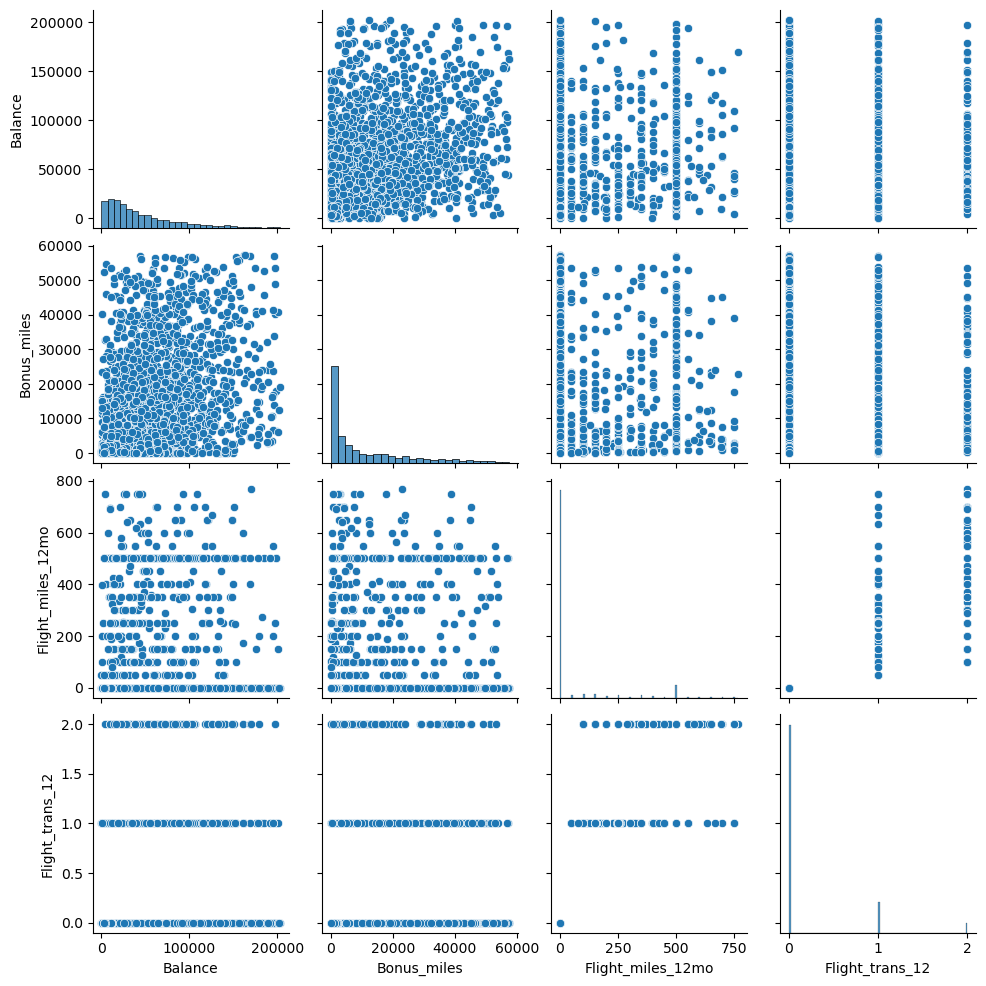

In [19]:
#Pair Plot
sns.pairplot(X_clean[["Balance","Bonus_miles","Flight_miles_12mo","Flight_trans_12"]])
plt.show()

In [20]:
print("Final dataset shape:", X_scaled.shape)
print("\nFeatures used for clustering:")
print(X_scaled.columns.tolist())
X_scaled.head()

Final dataset shape: (2875, 11)

Features used for clustering:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,-0.623072
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,-0.623072
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,-0.623072
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,-0.623072
5,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,-0.623072


**2.Imprmenting Clustering algrtnm**

K-means Clustering

In [21]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[23000.000000000007, 16416.78485142319, 12660.2963664761, 11346.674780463132, 10155.056775669527, 9194.24462742053, 8301.711111799503, 7677.952342432527, 7237.507449329257, 6846.435871547825]


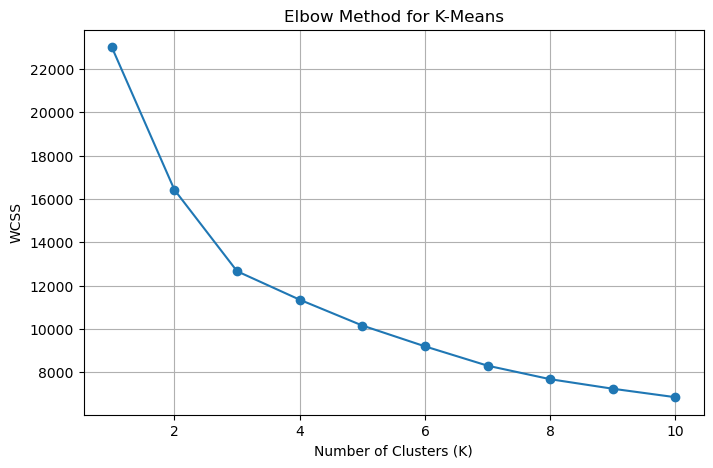

In [22]:
#plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

The elbow point in the graph indicates a suitable number of clusters. Use the K value where the decrease in WCSS starts becoming smaller.

In [23]:
#apply k-means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("K-Means Cluster Labels:")
print(kmeans_labels)

K-Means Cluster Labels:
[0 0 0 ... 1 2 0]


In [24]:
#add k-means cluster
X_kmeans = X_clean.copy()
X_kmeans["KMeans_Cluster"] = kmeans_labels
X_kmeans.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
5,16420,0,1,1,1,0,0,0,0,6942,0,0


In [25]:
#count
print(
    X_kmeans["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)


KMeans_Cluster
0    1543
1     453
2     340
3     539
Name: count, dtype: int64


In [26]:
#k-means silhouette score
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)
print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)


K-Means Silhouette Score: 0.3208


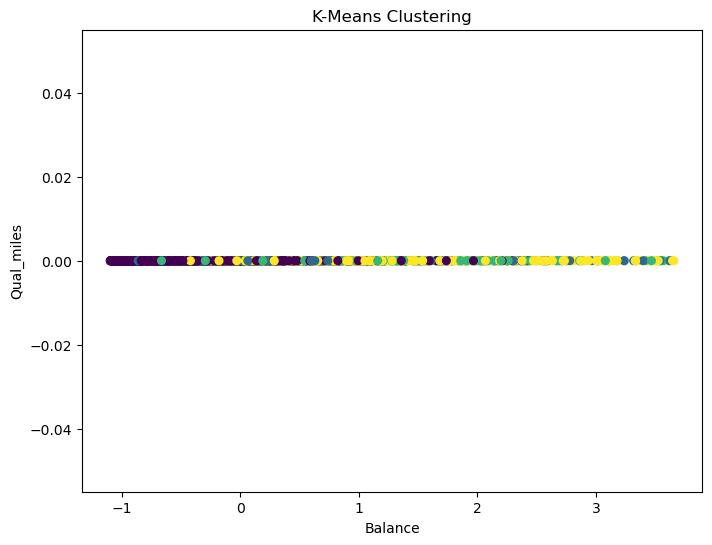

In [27]:
#k-means visulztn
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30
)
plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title("K-Means Clustering")
plt.show()

DBSCAN Clustering

DBSCAN uses two important parameters:

eps → maximum distance between neighbouring points

min_samples (minPts) → minimum number of points required to form a dense region

In [28]:
#apply DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)
print("DBSCAN Cluster Labels:")
print(dbscan_labels)

DBSCAN Cluster Labels:
[0 0 0 ... 2 3 0]


In [29]:
#add dbscan cluster labels
X_dbscan = X_clean.copy()
X_dbscan["DBSCAN_Cluster"] = dbscan_labels
X_dbscan.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
5,16420,0,1,1,1,0,0,0,0,6942,0,0


In [30]:
#count
print(
    X_dbscan["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

DBSCAN_Cluster
-1     115
 0    1805
 1     124
 2     602
 3     180
 4      37
 5       7
 6       5
Name: count, dtype: int64


In [31]:
#expriment with diff dbscan parameters
eps_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    labels = dbscan.fit_predict(X_scaled)
    clusters = set(labels) - {-1}
    if len(clusters) >= 2:
        mask = labels != -1
        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )
        print(
            "eps =", eps,
            "| Clusters =", len(clusters),
            "| Silhouette Score =", round(score, 4)
        )
    else:
        print(
            "eps =", eps,
            "| Not enough clusters"
        )

eps = 0.5 | Clusters = 19 | Silhouette Score = 0.113
eps = 0.75 | Clusters = 18 | Silhouette Score = 0.1965
eps = 1.0 | Clusters = 14 | Silhouette Score = 0.1841
eps = 1.25 | Clusters = 6 | Silhouette Score = 0.267
eps = 1.5 | Clusters = 7 | Silhouette Score = 0.2673
eps = 2.0 | Clusters = 7 | Silhouette Score = 0.2628


In [32]:
#exprmnt with diff minpts values
min_samples_values = [3, 5, 7, 10]

for min_samples in min_samples_values:

    dbscan = DBSCAN(
        eps=1.5,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(X_scaled)

    clusters = set(labels) - {-1}

    if len(clusters) >= 2:

        mask = labels != -1

        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        print(
            "minPts =", min_samples,
            "| Clusters =", len(clusters),
            "| Silhouette Score =", round(score, 4)
        )

    else:
        print(
            "minPts =", min_samples,
            "| Not enough clusters"
        )

minPts = 3 | Clusters = 12 | Silhouette Score = 0.2324
minPts = 5 | Clusters = 7 | Silhouette Score = 0.2673
minPts = 7 | Clusters = 5 | Silhouette Score = 0.2789
minPts = 10 | Clusters = 6 | Silhouette Score = 0.2656


In [33]:
#dbcsan silhouette
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)
unique_clusters = set(dbscan_labels) - {-1}
if len(unique_clusters) >= 2:

    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )

else:
    print("Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score: 0.2673


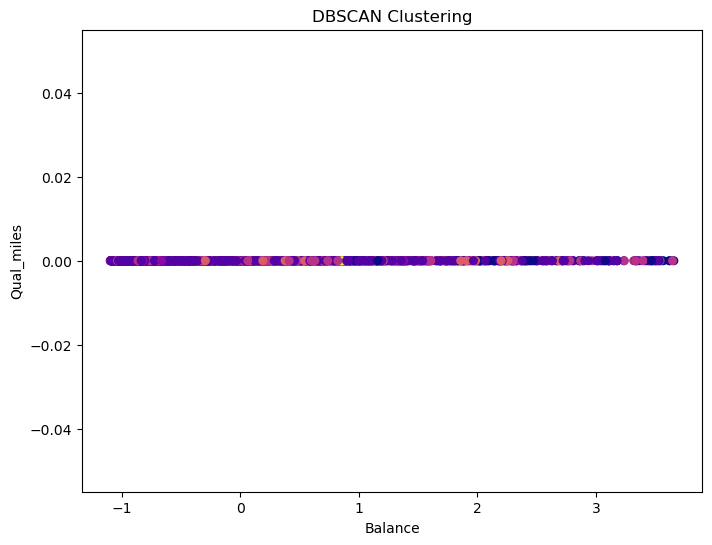

In [34]:
#visualization
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=dbscan_labels,
    cmap="plasma",
    s=30
)
plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title("DBSCAN Clustering")
plt.show()

In [36]:
#compare k-means and dbscan
print("Clustering Performance")
print("----------------------")

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)
if len(unique_clusters) >= 2:
    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )
else:
    print(
        "DBSCAN Silhouette Score: Not Available"
    )

Clustering Performance
----------------------
K-Means Silhouette Score: 0.3208
DBSCAN Silhouette Score: 0.2673


K-Means: The Elbow Method is used to identify a suitable value of K, and the Silhouette Score is used to evaluate the resulting clusters.

DBSCAN: Different eps and minPts values are tested to identify suitable density-based clusters. DBSCAN can also identify noise points using cluster label -1.

**3.Cluster Analysis and Interpretation**

k-means cluster analysis

In [41]:
kmeans_summary=X_kmeans.groupby('KMeans_Cluster').mean()
kmeans_summary

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,26357.586520,0.0,1.042126,1.0,1.0,2289.062216,4.773817,4.451717,0.036293,3527.233312,0.127025
1,53761.516556,0.0,3.130243,1.0,1.0,25830.536424,15.997792,12.152318,0.083885,4594.485651,1.000000
2,64862.867647,0.0,2.000000,1.0,1.0,13874.029412,11.423529,436.758824,1.320588,4123.497059,0.438235
3,88290.831169,0.0,2.884972,1.0,1.0,20981.909091,15.745826,6.025974,0.051948,4386.265306,0.011132


In [42]:
# Number of customers in each K-Means cluster
kmeans_cluster_size = X_kmeans[
    "KMeans_Cluster"
].value_counts().sort_index()

print(kmeans_cluster_size)

KMeans_Cluster
0    1543
1     453
2     340
3     539
Name: count, dtype: int64


In [43]:
print("K-Means Cluster Characteristics:")
print(kmeans_summary.round(2))

K-Means Cluster Characteristics:
                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                          
0               26357.59         0.0       1.04        1.0        1.0   
1               53761.52         0.0       3.13        1.0        1.0   
2               64862.87         0.0       2.00        1.0        1.0   
3               88290.83         0.0       2.88        1.0        1.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                 
0                   2289.06         4.77               4.45             0.04   
1                  25830.54        16.00              12.15             0.08   
2                  13874.03        11.42             436.76             1.32   
3                  20981.91        15.75               6.03             0.05   

                Days_since_enroll  Award?  
KMe

Clustering:

Cluster 0:Represents customers with relatively lower activity and lower mileage/bonus values.

Cluster 1: Represents customers with higher flight activity and mileage compared with other groups.

Cluster 2: Represents customers with moderate airline usage and loyalty activity.

Cluster 3: Represents customers with comparatively higher balance and bonus-mile activity.

Overall, K-Means successfully separates customers into groups based on their travel and loyalty-program behaviour.

DBSCAN Clustering:

DBSCAN groups customers based on the density of similar observations.

Customers within the same cluster have similar travel and loyalty characteristics.

The -1 cluster represents noise/outlier observations that do not belong to a dense group.

DBSCAN Cluster Analysis

In [45]:
dbscan_summary=X_dbscan.groupby('DBSCAN_Cluster').mean()
dbscan_summary

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
DBSCAN_Cluster,,,,,,,,,,,
-1,103574.400000,0.0,2.626087,1.0,1.0,21837.817391,17.382609,368.356522,1.469565,4901.565217,0.617391
0,42801.730194,0.0,1.567867,1.0,1.0,7473.067590,7.873684,0.000000,0.000000,3717.924100,0.000000
1,41631.967742,0.0,2.411290,1.0,1.0,19086.629032,11.838710,338.854839,1.000000,4091.209677,1.000000
2,46506.757475,0.0,2.431894,1.0,1.0,18152.727575,12.192691,0.000000,0.000000,4391.569767,1.000000
3,57542.688889,0.0,1.694444,1.0,1.0,9664.983333,9.205556,322.661111,1.000000,3885.416667,0.000000
4,39179.270270,0.0,1.027027,1.0,1.0,2568.972973,5.270270,433.486486,2.000000,3613.297297,0.000000
5,24826.714286,0.0,1.000000,1.0,1.0,3270.857143,6.142857,396.142857,2.000000,2555.428571,1.000000
6,71428.200000,0.0,3.200000,1.0,1.0,21422.000000,14.000000,570.000000,2.000000,2697.200000,0.000000


In [46]:
print("DBSCAN Cluster Sizes:")
print(
    X_dbscan[
        "DBSCAN_Cluster"
    ].value_counts().sort_index()
)

DBSCAN Cluster Sizes:
DBSCAN_Cluster
-1     115
 0    1805
 1     124
 2     602
 3     180
 4      37
 5       7
 6       5
Name: count, dtype: int64


In [47]:
noise_count = (
    X_dbscan["DBSCAN_Cluster"] == -1
).sum()

print("Number of noise points:", noise_count)

Number of noise points: 115


**4.Visualization**


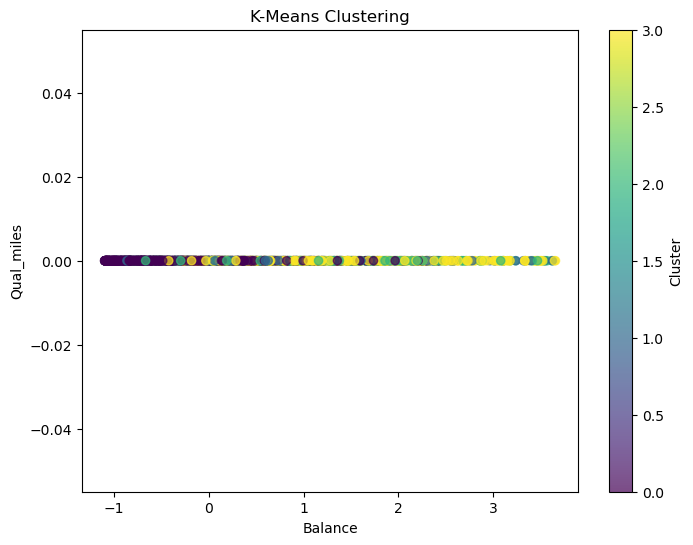

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=35,
    alpha=0.7
)
plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title("K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

DBSCAN cluster visualization

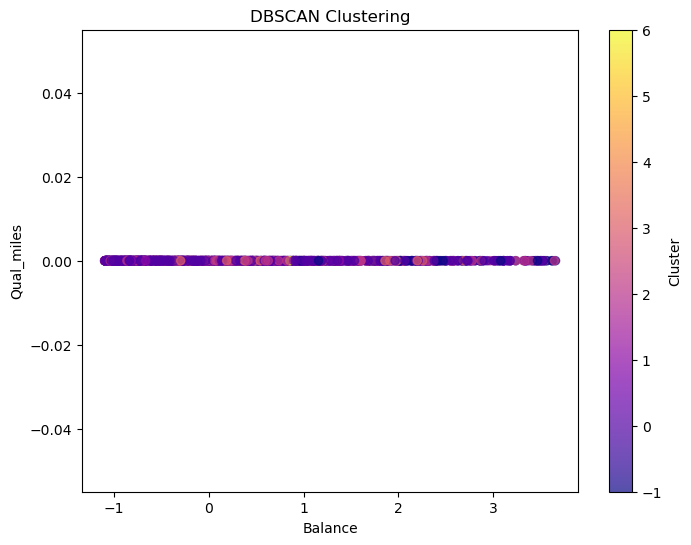

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=dbscan_labels,
    cmap="plasma",
    s=35,
    alpha=0.7
)
plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title("DBSCAN Clustering")
plt.colorbar(label="Cluster")
plt.show()

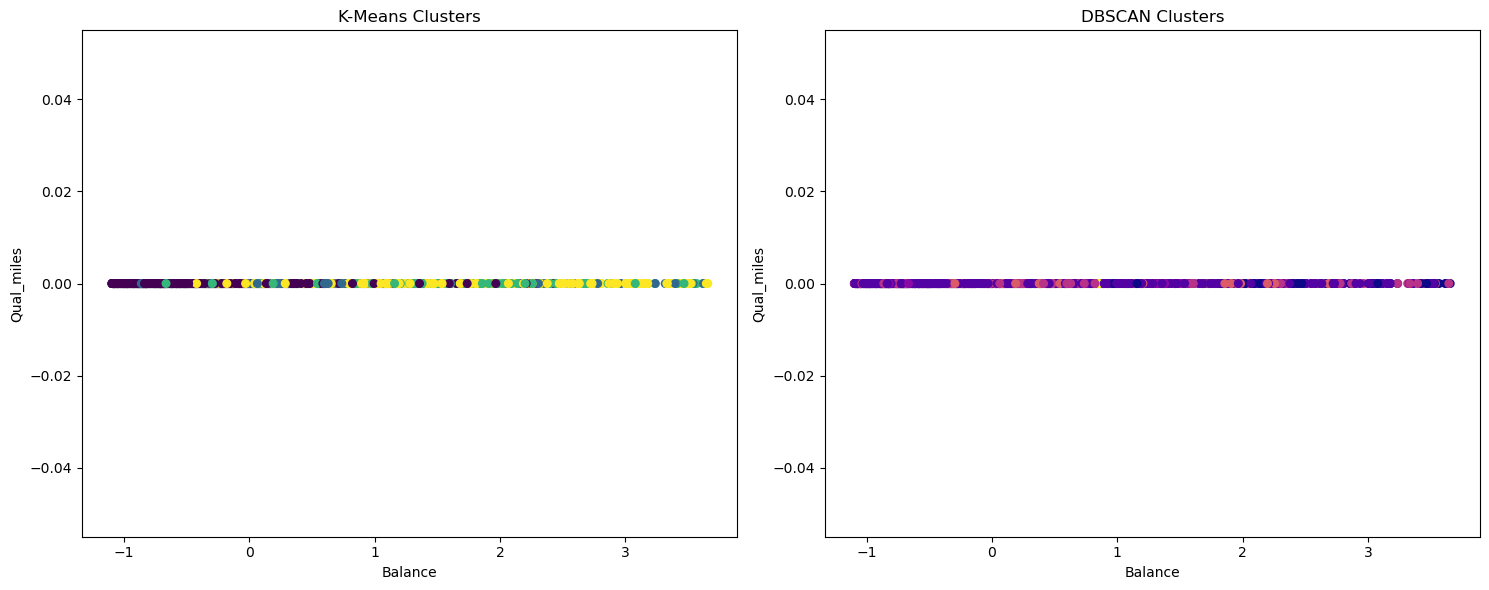

In [52]:
#compare k means and dbscan 
fig, axes = plt.subplots(1, 2,figsize=(15, 6))
# K-Means
axes[0].scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel(X_scaled.columns[0])
axes[0].set_ylabel(X_scaled.columns[1])
# DBSCAN
axes[1].scatter(
    X_scaled.iloc[:, 0],
    X_scaled.iloc[:, 1],
    c=dbscan_labels,
    cmap="plasma",
    s=30
)
axes[1].set_title("DBSCAN Clusters")
axes[1].set_xlabel(X_scaled.columns[0])
axes[1].set_ylabel(X_scaled.columns[1])
plt.tight_layout()
plt.show()


**5.Evaluation and Performance Metrics**

k-means silhouette score


In [53]:
from sklearn.metrics import silhouette_score
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)
print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

K-Means Silhouette Score: 0.3208


dbscan score

In [54]:
dbscan_clusters = set(dbscan_labels) - {-1}
if len(dbscan_clusters) >= 2:

    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )
else:
    print(
        "DBSCAN does not have enough clusters "
        "to calculate Silhouette Score."
    )

DBSCAN Silhouette Score: 0.2673


In [55]:
print("----- Clustering Performance -----")

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)
if len(dbscan_clusters) >= 2:
    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )
else:
    print("DBSCAN Silhouette Score: Not Available")

----- Clustering Performance -----
K-Means Silhouette Score: 0.3208
DBSCAN Silhouette Score: 0.2673


In [56]:
if len(dbscan_clusters) >= 2:

    if kmeans_silhouette > dbscan_silhouette:
        print(
            "K-Means produced a higher Silhouette Score "
            "and therefore showed better cluster separation "
            "for this dataset."
        )
    elif dbscan_silhouette > kmeans_silhouette:
        print(
            "DBSCAN produced a higher Silhouette Score "
            "and therefore showed better cluster separation "
            "for this dataset."
        )
    else:
        print(
            "Both algorithms produced the same Silhouette Score."
        )
else:
    print(
        "DBSCAN could not be compared using Silhouette Score "
        "because it did not produce enough clusters."
    )

K-Means produced a higher Silhouette Score and therefore showed better cluster separation for this dataset.


Conclusion:

K-Means and DBSCAN clustering algorithms were successfully applied to the EastWest Airlines dataset. The data was preprocessed by handling missing values, removing outliers, and scaling the features. EDA and visualizations helped identify patterns and customer groups. K-Means divided customers into different clusters, while DBSCAN identified dense groups and noise points. The Silhouette Score was used to evaluate the quality of the clusters. Overall, clustering helps identify different customer segments based on their travel and loyalty behaviour, which can support targeted marketing and customer-loyalty strategies.